Text(0.5, 1.0, 'dispL')

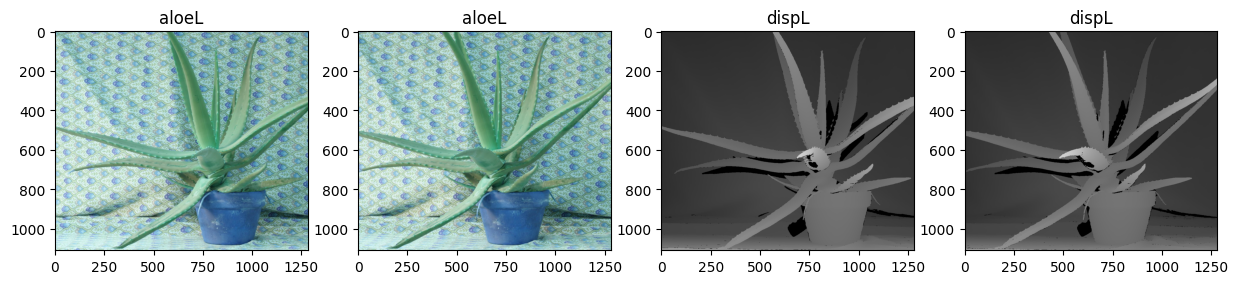

In [1]:
import cv2
import matplotlib.pyplot as plt

aloeL = cv2.imread("aloes/aloeL.jpg")
aloeR = cv2.imread("aloes/aloeR.jpg")
dispL = cv2.imread("aloes/dispL.png")
dispR = cv2.imread("aloes/dispR.png")

fig, ax = plt.subplots(1, 4, figsize=(15, 8))
ax[0].imshow(aloeL)
ax[0].set_title("aloeL")
ax[1].imshow(aloeR)
ax[1].set_title("aloeL")
ax[2].imshow(dispL)
ax[2].set_title("dispL")
ax[3].imshow(dispR)
ax[3].set_title("dispL")



In [60]:
from operator import xor
import numpy as np

def censusa(image_left, image_right, border=2, dmax=10):

    YY, XX = image_left.shape

    disparity_image = np.zeros_like(image_left)

    for y in range(border, YY - border):
        for x in range(border, XX - border):
            frame_l = image_left[y-border: y+border+1, x-border: x+border+1]
            middle_l = frame_l[border, border]
            _, binary_frame_left = cv2.threshold(frame_l, middle_l-1, 1, cv2.THRESH_BINARY)

            similar = np.inf
            disp = 0
            for d in range(dmax):
                if(x+d+border+1 > XX):
                    continue
                frame_r = image_right[y-border: y+border+1, x-border+d: x+d+border+1]
                _, binary_frame_right = cv2.threshold(frame_r, middle_l-1, 1, cv2.THRESH_BINARY)
                xor_result = np.bitwise_xor(binary_frame_left, binary_frame_right)
                actual_similar = np.sum(xor_result)
                if(actual_similar < similar):
                    similar = actual_similar
                    disp = d
                    
                
            disparity_image[y, x] = disp

    disparity_image_scaled = disparity_image * 25

    return disparity_image_scaled



In [61]:
disparity_image = censusa(cv2.cvtColor(aloeL, cv2.COLOR_BGR2GRAY), cv2.cvtColor(aloeR, cv2.COLOR_BGR2GRAY))

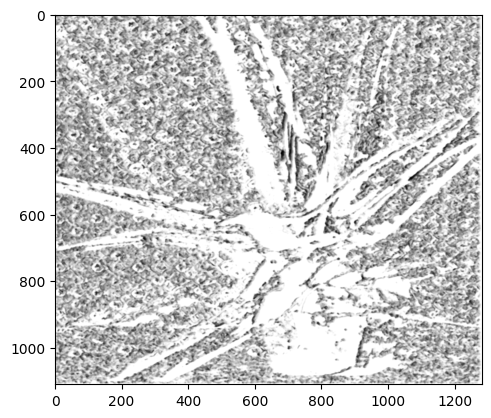

In [62]:
disparity_image_white = 255 - disparity_image
disparity_image_white = cv2.GaussianBlur(disparity_image_white.astype("uint8"), (5, 5), 1)
disparity_image_white = cv2.medianBlur(disparity_image_white.astype("uint8"), 5) 
plt.imshow(disparity_image_white, cmap="gray")

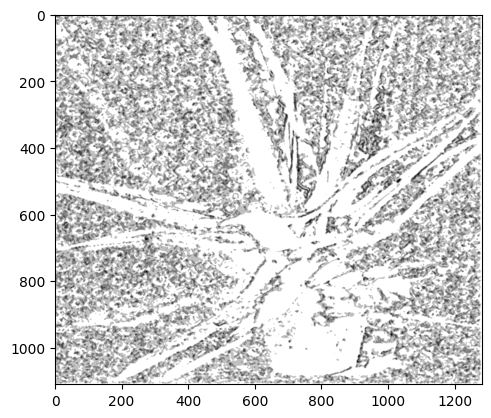

In [50]:
disparity_image_white = 255 - disparity_image
disparity_image_white = cv2.GaussianBlur(disparity_image_white.astype("uint8"), (5, 5), 1)
disparity_image_white = cv2.medianBlur(disparity_image_white.astype("uint8"), 5) 
plt.imshow(disparity_image_white, cmap="gray")

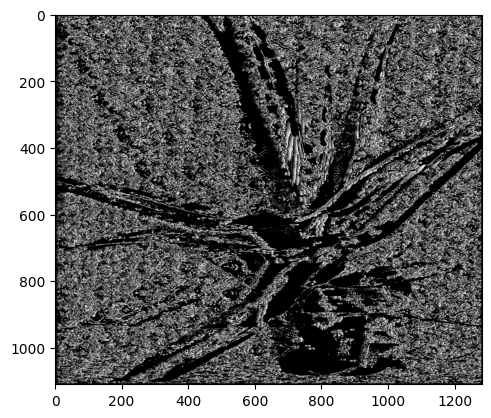

In [53]:
aloe_l_resize = cv2.resize(aloeL, (0, 0), fx=0.5, fy=0.5)
aloe_l_resize = cv2.cvtColor(aloeL, cv2.COLOR_BGR2GRAY)

aloe_r_resize = cv2.resize(aloeR, (0, 0), fx=0.5, fy=0.5)
aloe_r_resize = cv2.cvtColor(aloeR, cv2.COLOR_BGR2GRAY)

biggest_d = censusa(aloe_l_resize, aloe_r_resize, border=2, dmax=20)
plt.imshow(biggest_d, cmap='gray')

In [26]:
import numpy as np

def census_transform(image1, image2, block_size=5, dmax=5):
    """
    Implementacja transformacji Censusa dla dwóch obrazów.
    
    :param image1: Pierwszy obraz wejściowy jako macierz NumPy.
    :param image2: Drugi obraz wejściowy jako macierz NumPy.
    :param block_size: Rozmiar bloku NxN.
    :param dmax: Maksymalne przesunięcie dla drugiego obrazu.
    :return: Mapa wartości d dla każdego piksela.
    """
    half_size = block_size // 2
    height, width = image1.shape
    census_map = np.zeros_like(image1, dtype=int)
    
    for y in range(half_size, height - half_size):
        for x in range(half_size, width - half_size):
            block1 = image1[y - half_size:y + half_size + 1, x - half_size:x + half_size + 1]
            threshold = block1[half_size, half_size]
            binary_pattern1 = (block1 >= threshold).astype(int).flatten()
            
            min_diff = float('inf')
            best_d = 0
            
            for d in range(dmax):
                shifted_x = min(x + d, width - half_size - 1)
                block2 = image2[y - half_size:y + half_size + 1, shifted_x - half_size:shifted_x + half_size + 1]
                binary_pattern2 = (block2 >= threshold).astype(int).flatten()
                
                xor_result = np.bitwise_xor(binary_pattern1, binary_pattern2)
                diff_count = np.sum(xor_result)
                
                if diff_count < min_diff:
                    min_diff = diff_count
                    best_d = d
            
            census_map[y, x] = best_d
    
    return census_map


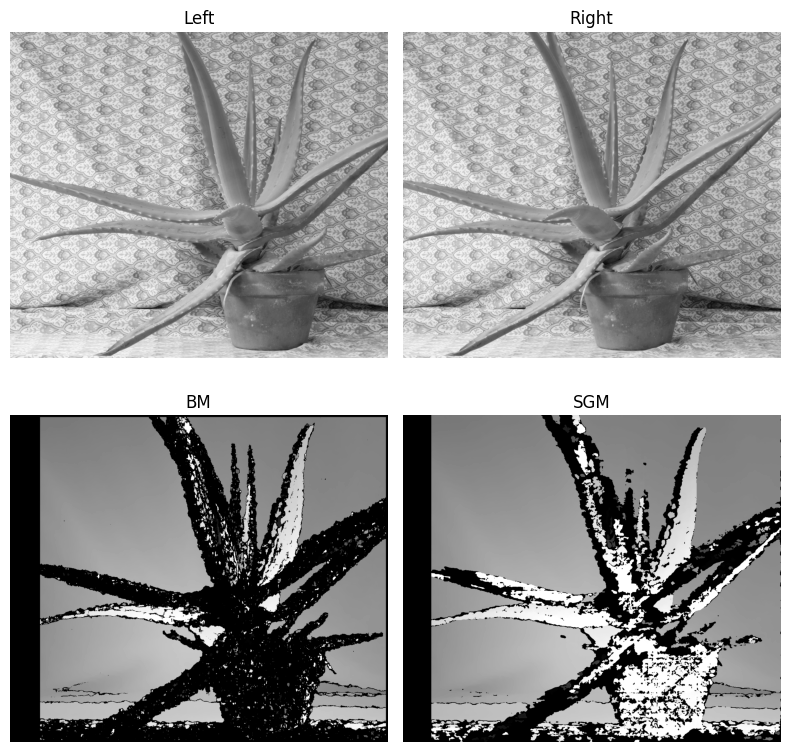

In [59]:

def get_disparity_map(dst_L, dst_R):
    dst_L = cv2.cvtColor(dst_L, cv2.COLOR_BGR2GRAY)
    dst_R = cv2.cvtColor(dst_R, cv2.COLOR_BGR2GRAY)

    stereo = cv2.StereoBM_create(numDisparities=16*6, blockSize=15)
    disparity_BM = stereo.compute(dst_L, dst_R)
    disparity_BM = cv2.normalize(disparity_BM, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)
    disparity_BM = np.uint8(disparity_BM)

    stereo = cv2.StereoSGBM_create(
        minDisparity=0,
        numDisparities=16*6,  # Liczba poziomów dysparycji
        blockSize=9,
        P1=8 * 3 * 9**2,  # Regularyzacja
        P2=32 * 3 * 9**2,
        disp12MaxDiff=1,
        uniquenessRatio=15,
        speckleWindowSize=100,
        speckleRange=32
    )
    disparity_SGM = stereo.compute(dst_L, dst_R)
    disparity_SGM = cv2.normalize(disparity_SGM, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)
    disparity_SGM = np.uint8(disparity_SGM)


    fig, ax = plt.subplots(2, 2, figsize=(8, 8))
    ax[0, 0].imshow(dst_L, cmap='gray')
    ax[0, 0].set_title("Left")
    ax[0, 0].axis("off")

    ax[0, 1].imshow(dst_R, cmap='gray')
    ax[0, 1].set_title("Right")
    ax[0, 1].axis("off")

    ax[1, 0].imshow(disparity_BM, cmap='gray')
    ax[1, 0].set_title("BM")
    ax[1, 0].axis("off")

    ax[1, 1].imshow(disparity_SGM,cmap='gray')
    ax[1, 1].set_title("SGM")
    ax[1, 1].axis("off")

    plt.tight_layout()
    plt.show()

get_disparity_map(np.uint8(aloeL), np.uint8(aloeR))